In [1]:
# Neural Network models for 401(k) example in Python (PyTorch)
# Four architectures on the same base network (Input -> 50 -> 50 -> 50 -> 50 -> Output, ReLU):
#   Model A: no explicit regularization
#   Model B: .5 dropout on hidden layers
#   Model C: L2 weight decay on all layers
#   Model D: early stopping

import os, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Reproducibility
SEED_DATA = 8261977   # data split
SEED_INIT = 724       # model init + training
np.random.seed(SEED_DATA)

# Load data
data_path = os.path.join("..", "Data", "restatw.dat")
data = pd.read_csv(data_path, sep=r"\s+")

cols_to_keep = ["net_tfa", "e401", "age", "inc", "educ", "fsize",
                "marr", "twoearn", "db", "pira", "hown"]
data = data[cols_to_keep]

# Normalize select columns
data["age"]   /= 64
data["inc"]   /= 250000
data["fsize"] /= 13
data["educ"]  /= 18

# Train/test split (8000 train obs, rest test)
train_idx = np.random.choice(data.index, size=8000, replace=False)
test_idx  = np.setdiff1d(data.index, train_idx)
train = data.loc[train_idx]
test  = data.loc[test_idx]

train_X = train.drop(columns=["net_tfa"]).values
train_y = train["net_tfa"].values.astype(np.float32)
test_X  = test.drop(columns=["net_tfa"]).values
test_y  = test["net_tfa"].values.astype(np.float32)

scaler = StandardScaler()
train_X = scaler.fit_transform(train_X).astype(np.float32)
test_X  = scaler.transform(test_X).astype(np.float32)
p = train_X.shape[1]

# Split train -> sub-train (80%) + val (20%) for loss monitoring
nval = int(round(0.2 * len(train_X)))
nsub = len(train_X) - nval
sub_X, val_X = train_X[:nsub], train_X[nsub:]
sub_y, val_y = train_y[:nsub], train_y[nsub:]

# Tensors
def _t(a):
    a = np.asarray(a, dtype=np.float32)
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    return torch.from_numpy(a)
sub_Xt, val_Xt, test_Xt = _t(sub_X), _t(val_X), _t(test_X)
sub_yt, val_yt, test_yt = _t(sub_y), _t(val_y), _t(test_y)

def make_mlp(p, hidden=50, n_hidden=4, dropout=0.0):
    layers = [nn.Linear(p, hidden), nn.ReLU()]
    if dropout > 0:
        layers.append(nn.Dropout(dropout))
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(hidden, 1))
    return nn.Sequential(*layers)

def fit_model(model, epochs=200, batch_size=200, lr=1e-3,
              weight_decay=0.0, early_stop_patience=None, seed=SEED_INIT):
    torch.manual_seed(seed)
    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    dl = DataLoader(TensorDataset(sub_Xt, sub_yt), batch_size=batch_size,
                    shuffle=True, generator=torch.Generator().manual_seed(seed))
    train_hist, val_hist = [], []
    best_val, best_state, best_epoch, patience = float("inf"), None, 0, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_hist.append(loss_fn(model(sub_Xt), sub_yt).item())
            v = loss_fn(model(val_Xt), val_yt).item()
            val_hist.append(v)
        if early_stop_patience is not None:
            if v < best_val:
                best_val, best_state, best_epoch, patience = v, copy.deepcopy(model.state_dict()), epoch, 0
            else:
                patience += 1
                if patience >= early_stop_patience:
                    break
    if early_stop_patience is not None and best_state is not None:
        model.load_state_dict(best_state)
    return np.array(train_hist), np.array(val_hist), best_epoch

def eval_r2(model, X_t, y):
    model.eval()
    with torch.no_grad():
        yhat = model(X_t).numpy().flatten()
    return r2_score(y, yhat)

def plot_history(th, vh, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.sqrt(th), label="train")
    ax.plot(np.sqrt(vh), label="val")
    ax.set_xlabel("epoch"); ax.set_ylabel("RMSE"); ax.set_title(title); ax.legend()
    ax.grid(True); plt.show()

print(f"Train {sub_X.shape}, Val {val_X.shape}, Test {test_X.shape}")

Train (6400, 10), Val (1600, 10), Test (1915, 10)


Model A: Validation R^2 = 0.2155


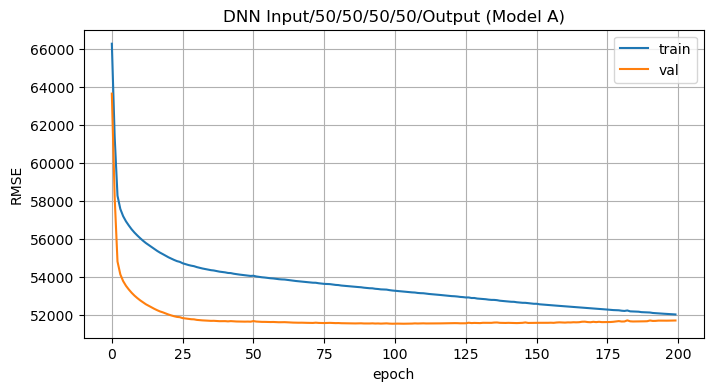

In [2]:
# Model A: Input/50/50/50/50/Output, ReLU, no regularization
torch.manual_seed(SEED_INIT)
model_A = make_mlp(p)
th_A, vh_A, _ = fit_model(model_A)
r2_A = eval_r2(model_A, test_Xt, test_y)
print(f"Model A: Validation R^2 = {r2_A:.4f}")
plot_history(th_A, vh_A, "DNN Input/50/50/50/50/Output (Model A)")

Model B: Validation R^2 = 0.2335


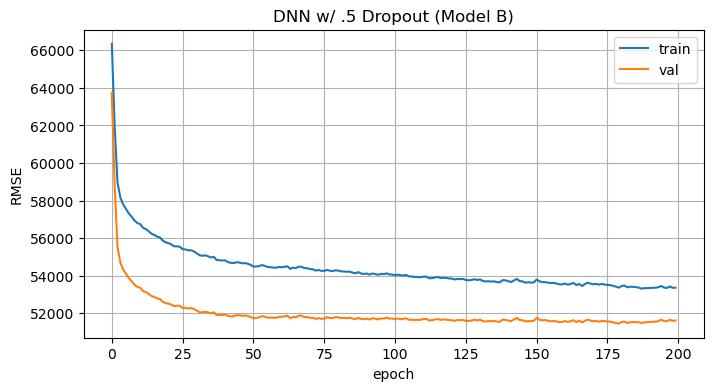

In [3]:
# Model B: same network with .5 dropout on hidden layers
torch.manual_seed(SEED_INIT)
model_B = make_mlp(p, dropout=0.5)
th_B, vh_B, _ = fit_model(model_B)
r2_B = eval_r2(model_B, test_Xt, test_y)
print(f"Model B: Validation R^2 = {r2_B:.4f}")
plot_history(th_B, vh_B, "DNN w/ .5 Dropout (Model B)")

Model C: Validation R^2 = 0.2153


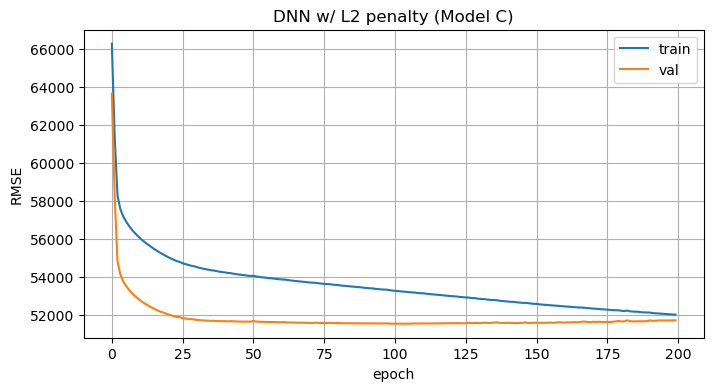

In [4]:
# Model C: same network with L2 weight decay (0.01) on all layers
torch.manual_seed(SEED_INIT)
model_C = make_mlp(p)
th_C, vh_C, _ = fit_model(model_C, weight_decay=0.01)
r2_C = eval_r2(model_C, test_Xt, test_y)
print(f"Model C: Validation R^2 = {r2_C:.4f}")
plot_history(th_C, vh_C, "DNN w/ L2 penalty (Model C)")

Model D: Validation R^2 = 0.2297  (best epoch = 103, ran 304 epochs)


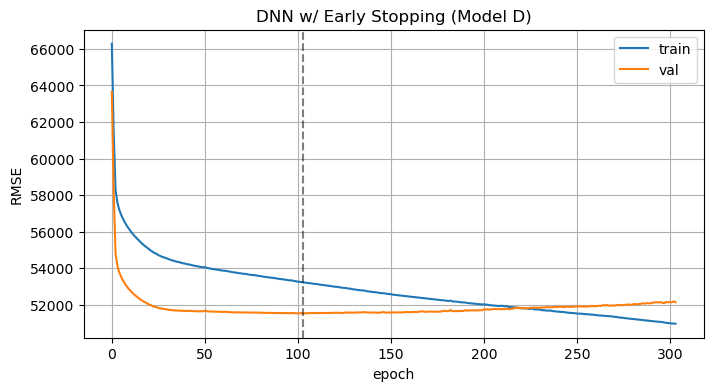


Summary of validation R^2:
  A (plain):        0.2155
  B (dropout 0.5):  0.2335
  C (L2 0.01):      0.2153
  D (early stop):   0.2297


In [5]:
# Model D: same network with early stopping (patience 200, max 2000 epochs)
torch.manual_seed(SEED_INIT)
model_D = make_mlp(p)
th_D, vh_D, best_ep = fit_model(model_D, epochs=2000, early_stop_patience=200)
r2_D = eval_r2(model_D, test_Xt, test_y)
print(f"Model D: Validation R^2 = {r2_D:.4f}  (best epoch = {best_ep}, ran {len(vh_D)} epochs)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.sqrt(th_D), label="train")
ax.plot(np.sqrt(vh_D), label="val")
ax.axvline(best_ep, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("RMSE")
ax.set_title("DNN w/ Early Stopping (Model D)"); ax.legend(); ax.grid(True)
plt.show()

print("\nSummary of validation R^2:")
print(f"  A (plain):        {r2_A:.4f}")
print(f"  B (dropout 0.5):  {r2_B:.4f}")
print(f"  C (L2 0.01):      {r2_C:.4f}")
print(f"  D (early stop):   {r2_D:.4f}")